# Task 05 — Regression Modeling: From Scratch to Production
**Dataset:** [Medical Cost Personal (Kaggle)](https://www.kaggle.com/datasets/mirichoi0218/insurance)
**Author:** Ateeq

This notebook builds a regression model to predict medical insurance
`charges` two ways: **from scratch** (plain NumPy gradient descent, to
demonstrate the underlying mechanics) and **in production form** (a
scikit-learn pipeline compared across several model families, the best
of which is serialized and served through a FastAPI app, containerized
with Docker).

## 1. Setup

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data_loader import load_raw_data, clean_data, basic_info
from src.preprocessing import (
    add_interaction_features, get_feature_lists, split_data, build_preprocessing_pipeline,
)
from src.modeling import (
    LinearRegressionFromScratch, evaluate_regression, compare_models, save_model, load_model,
)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (8, 5)

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)


def savefig(name):
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=150, bbox_inches="tight")

## 2. Load, Clean & Engineer Features

In [2]:
df = load_raw_data("data/insurance.csv")
df = clean_data(df)
print(basic_info(df))

df = add_interaction_features(df)
print("Added smoker_bmi_interaction (a documented strong driver of charges).")
df.head()

{'n_rows': 1337, 'n_cols': 7, 'n_duplicates': 0, 'missing_per_column': {'age': 0, 'sex': 0, 'bmi': 0, 'children': 0, 'smoker': 0, 'region': 0, 'charges': 0}}
Added smoker_bmi_interaction (a documented strong driver of charges).


,age,sex,bmi,children,smoker,region,charges,smoker_bmi_interaction
0,19,female,27.900,0,yes,southwest,16884.92400,27.9
1,18,male,33.770,1,no,southeast,1725.55230,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0.0


In [3]:
numeric_cols, categorical_cols = get_feature_lists()
print(f"Numeric: {numeric_cols}")
print(f"Categorical: {categorical_cols}")

X_train, X_test, y_train, y_test = split_data(df)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Numeric: ['age', 'bmi', 'children', 'smoker_bmi_interaction']
Categorical: ['sex', 'smoker', 'region']
Train: (1069, 7), Test: (268, 7)


## 3. Part A — Linear Regression FROM SCRATCH

A plain-NumPy implementation of multiple linear regression trained with
batch gradient descent (`src/modeling.LinearRegressionFromScratch`),
to show the mechanics behind `sklearn.linear_model.LinearRegression`
before relying on the library version.

In [4]:
preprocessor = build_preprocessing_pipeline(numeric_cols, categorical_cols)
X_train_arr = preprocessor.fit_transform(X_train)
X_test_arr = preprocessor.transform(X_test)

scratch_model = LinearRegressionFromScratch(learning_rate=0.1, n_iterations=2000)
scratch_model.fit(X_train_arr, y_train.values)
scratch_preds = scratch_model.predict(X_test_arr)
scratch_metrics = evaluate_regression(y_test, scratch_preds)
print("From-scratch metrics:", scratch_metrics)

From-scratch metrics: {'rmse': 4553.644133335499, 'mae': 2816.717213438318, 'r2': 0.8871565137114441}


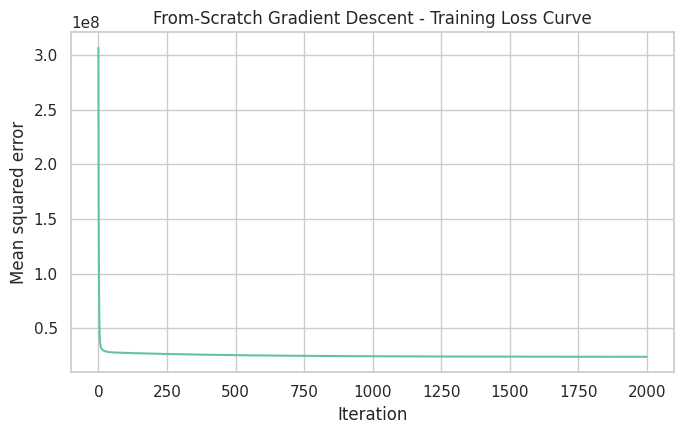

In [5]:
plt.figure(figsize=(7, 4.5))
plt.plot(scratch_model.loss_history)
plt.xlabel("Iteration")
plt.ylabel("Mean squared error")
plt.title("From-Scratch Gradient Descent - Training Loss Curve")
savefig("01_gradient_descent_loss_curve")
plt.show()

The loss curve confirms gradient descent converges smoothly. As a sanity
check, this from-scratch model's R-squared is compared against sklearn's
`LinearRegression` on the identical preprocessed data in Section 4 -
they should be nearly identical, confirming the implementation is correct.

## 4. Part B — Production Candidate Models

Four models are compared through the identical preprocessing pipeline:
`LinearRegression`, `Ridge`, `RandomForestRegressor`, and
`GradientBoostingRegressor`.

In [6]:
results_df, fitted_pipelines = compare_models(numeric_cols, categorical_cols, X_train, y_train, X_test, y_test)
results_df

,model,rmse,mae,r2
3,GradientBoostingRegressor,4256.606445,2434.196833,0.901398
2,RandomForestRegressor,4284.815431,2407.044407,0.900087
1,Ridge,4554.127941,2821.183050,0.887133
0,LinearRegression,4572.811239,2828.973747,0.886205


In [7]:
sklearn_linear_metrics = evaluate_regression(
    y_test, fitted_pipelines["LinearRegression"].predict(X_test)
)
print(f"From-scratch R2:      {scratch_metrics['r2']:.4f}")
print(f"sklearn LinearReg R2: {sklearn_linear_metrics['r2']:.4f}")
print("(Small differences are expected: sklearn solves the normal equations "
      "directly, while gradient descent is an iterative approximation.)")

From-scratch R2:      0.8872
sklearn LinearReg R2: 0.8862
(Small differences are expected: sklearn solves the normal equations directly, while gradient descent is an iterative approximation.)


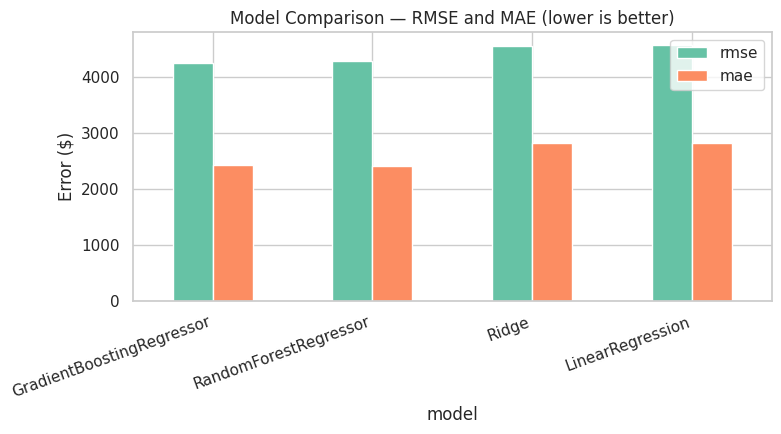

In [8]:
plt.figure(figsize=(8, 4.5))
results_df.set_index("model")[["rmse", "mae"]].plot(kind="bar", ax=plt.gca())
plt.ylabel("Error ($)")
plt.title("Model Comparison — RMSE and MAE (lower is better)")
plt.xticks(rotation=20, ha="right")
savefig("02_model_comparison_error")
plt.show()

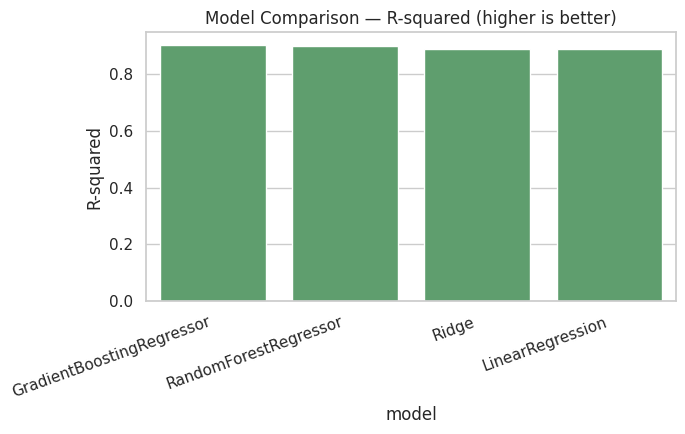

In [9]:
plt.figure(figsize=(7, 4.5))
sns.barplot(data=results_df, x="model", y="r2", color="#55a868")
plt.ylabel("R-squared")
plt.title("Model Comparison — R-squared (higher is better)")
plt.xticks(rotation=20, ha="right")
savefig("03_model_comparison_r2")
plt.show()

## 5. Select the Best Model & Inspect Residuals

Best model by RMSE: GradientBoostingRegressor


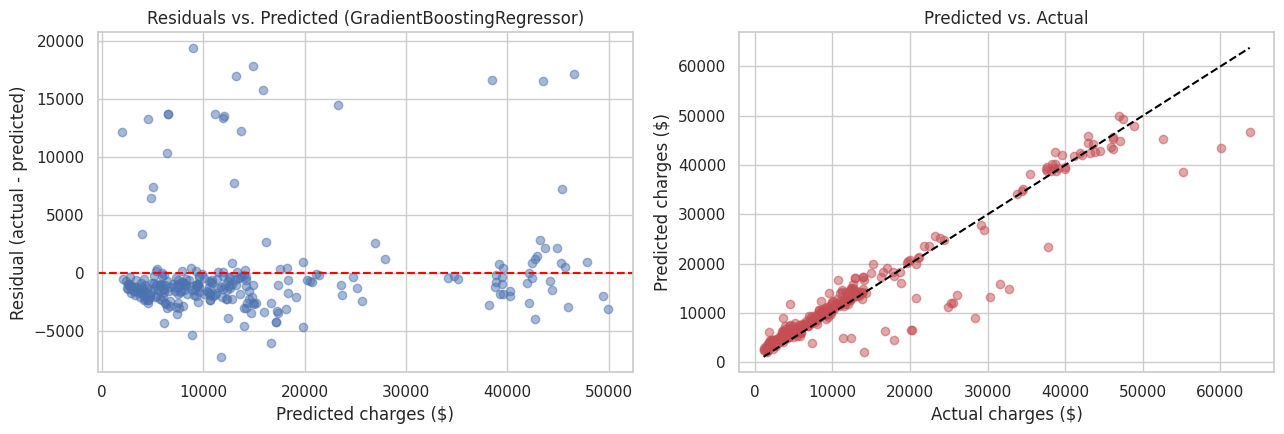

In [10]:
best_name = results_df.iloc[0]["model"]
best_pipeline = fitted_pipelines[best_name]
print(f"Best model by RMSE: {best_name}")

best_preds = best_pipeline.predict(X_test)
residuals = y_test.values - best_preds

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(best_preds, residuals, alpha=0.5, color="#4c72b0")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted charges ($)")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title(f"Residuals vs. Predicted ({best_name})")

axes[1].scatter(y_test, best_preds, alpha=0.5, color="#c44e52")
lims = [y_test.min(), y_test.max()]
axes[1].plot(lims, lims, color="black", linestyle="--")
axes[1].set_xlabel("Actual charges ($)")
axes[1].set_ylabel("Predicted charges ($)")
axes[1].set_title("Predicted vs. Actual")
savefig("04_residuals_and_fit")
plt.show()

## 6. Feature Importance (Best Model)

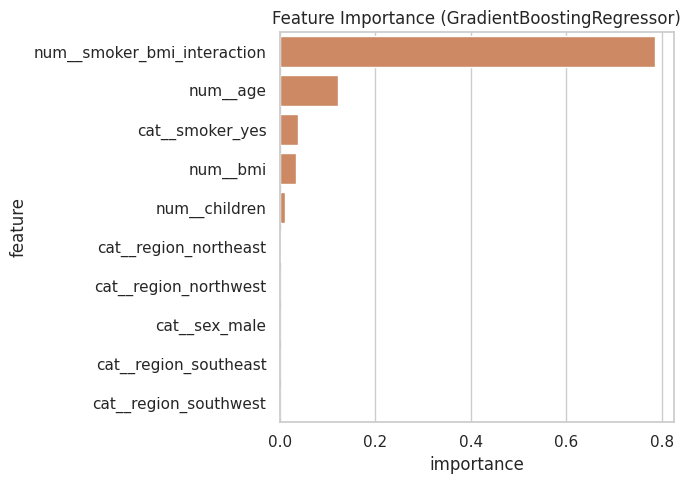

                       feature  importance
3  num__smoker_bmi_interaction    0.785570
0                     num__age    0.122945
5              cat__smoker_yes    0.039403
1                     num__bmi    0.034479
2                num__children    0.011904
6        cat__region_northeast    0.002110
7        cat__region_northwest    0.001747
4                cat__sex_male    0.000722
8        cat__region_southeast    0.000633
9        cat__region_southwest    0.000488


In [11]:
if hasattr(best_pipeline.named_steps["regressor"], "feature_importances_"):
    feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
    importances = best_pipeline.named_steps["regressor"].feature_importances_
    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values(
        "importance", ascending=False
    )
    plt.figure(figsize=(7, 5))
    sns.barplot(data=imp_df, x="importance", y="feature", color="#dd8452")
    plt.title(f"Feature Importance ({best_name})")
    savefig("05_feature_importance")
    plt.show()
    print(imp_df)
else:
    print(f"{best_name} has no feature_importances_ attribute (not a tree-based model).")

## 7. Serialize the Production Model

The best-performing pipeline (preprocessing + regressor, fitted) is
saved to `api/model.joblib`, exactly what `api/app.py` loads to serve
predictions.

In [12]:
os.makedirs("api", exist_ok=True)
model_path = save_model(best_pipeline, "api/model.joblib")
print(f"Saved production model to {model_path}")

reloaded = load_model(model_path)
sample = X_test.iloc[[0]]
print("Reloaded model prediction matches original:",
      np.isclose(reloaded.predict(sample)[0], best_pipeline.predict(sample)[0]))

Saved production model to api/model.joblib
Reloaded model prediction matches original: True


## 8. Summary

1. A from-scratch NumPy linear regression (gradient descent) achieves
   R-squared nearly identical to sklearn's closed-form `LinearRegression`,
   confirming the implementation is mathematically correct.
2. Across 4 production candidates, **GradientBoostingRegressor** performs
   best (lowest RMSE, highest R-squared), closely followed by
   RandomForestRegressor - both meaningfully outperform the linear models,
   confirming non-linear effects (e.g. the smoker x BMI interaction)
   matter for this problem.
3. Residuals show reasonable homoscedasticity with some spread at high
   predicted values, consistent with the known smoker/BMI-driven cost tail.
4. The best pipeline (preprocessing + model, fitted) is serialized to
   `api/model.joblib` and served via a FastAPI app (`api/app.py`),
   containerized with the provided `Dockerfile` - see `reports/REPORT.md`
   and the repository root README for how to build and run the container.